In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Better display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Load both months and combine
df_oct = pd.read_parquet('../data/raw/yellow_tripdata_2025-10.parquet')
df_nov = pd.read_parquet('../data/raw/yellow_tripdata_2025-11.parquet')

# Combine them
df = pd.concat([df_oct, df_nov], ignore_index=True)

print(f"✅ Data loaded successfully!")
print(f"October data: {len(df_oct):,} rows")
print(f"November data: {len(df_nov):,} rows")
print(f"Total: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

✅ Data loaded successfully!
October data: 4,428,699 rows
November data: 4,181,444 rows
Total: 8,610,143 rows × 20 columns

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-10-01 00:15:32,2025-10-01 01:04:03,1.0,17.20,2.0,N,132,107,1,70.0,5.00,0.5,0.00,6.94,1.0,83.44,2.5,1.75,0.75
1,7,2025-10-01 00:00:08,2025-10-01 00:00:08,1.0,5.00,1.0,N,107,225,1,28.2,0.00,0.5,8.49,0.00,1.0,42.44,2.5,0.00,0.75
2,2,2025-10-01 00:08:54,2025-10-01 00:14:44,1.0,2.75,1.0,N,263,229,1,12.8,1.00,0.5,3.71,0.00,1.0,22.26,2.5,0.00,0.75
3,1,2025-10-01 00:58:48,2025-10-01 01:04:40,1.0,1.30,1.0,N,211,231,2,7.9,4.25,0.5,0.00,0.00,1.0,13.65,2.5,0.00,0.75
4,2,2025-10-01 00:39:51,2025-10-01 00:49:40,1.0,2.88,1.0,N,230,151,1,14.2,1.00,0.5,3.99,0.00,1.0,23.94,2.5,0.00,0.75


In [5]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,8.610143e+06,8610143,8610143,6.604516e+06,8.610143e+06,6.604516e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,8.610143e+06,6.604516e+06,6.604516e+06,8.610143e+06
mean,1.880449e+00,2025-10-31 05:14:47.973420,2025-10-31 05:33:19.094373,1.280705e+00,6.616210e+00,4.251681e+00,1.620136e+02,1.616301e+02,9.239439e-01,1.770307e+01,1.119277e+00,4.797811e-01,2.928462e+00,5.245257e-01,9.473213e-01,2.631377e+01,2.179078e+00,1.450797e-01,5.352952e-01
min,1.000000e+00,2008-12-31 23:04:21,2008-12-31 23:32:25,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.508700e+03,-8.500000e+00,-5.000000e-01,-3.333300e+02,-1.150500e+02,-1.000000e+00,-1.514450e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-10-16 14:23:45.500000,2025-10-16 14:47:47,1.000000e+00,1.050000e+00,1.000000e+00,1.160000e+02,1.070000e+02,1.000000e+00,7.900000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.505000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-10-31 11:22:39,2025-10-31 11:41:59,1.000000e+00,1.890000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.350000e+01,0.000000e+00,5.000000e-01,2.110000e+00,0.000000e+00,1.000000e+00,2.105000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-11-14 22:01:46,2025-11-14 22:19:05,1.000000e+00,3.840000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.244000e+01,2.500000e+00,5.000000e-01,4.050000e+00,0.000000e+00,1.000000e+00,3.066000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-11-30 23:59:59,2025-12-01 21:41:00,9.000000e+00,2.763335e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.508700e+03,2.369000e+01,1.050000e+01,5.750000e+02,3.000000e+02,2.500000e+00,1.514450e+03,2.500000e+00,6.750000e+00,7.500000e-01
std,7.535625e-01,NaN,NaN,6.976503e-01,6.428045e+02,1.726792e+01,6.620456e+01,7.048791e+01,7.123544e-01,1.964374e+01,1.782327e+00,1.276949e-01,4.043468e+00,2.155351e+00,2.771385e-01,2.395217e+01,9.344312e-01,5.259107e-01,3.536909e-01


In [6]:
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


Missing Values:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          2005627
trip_distance           

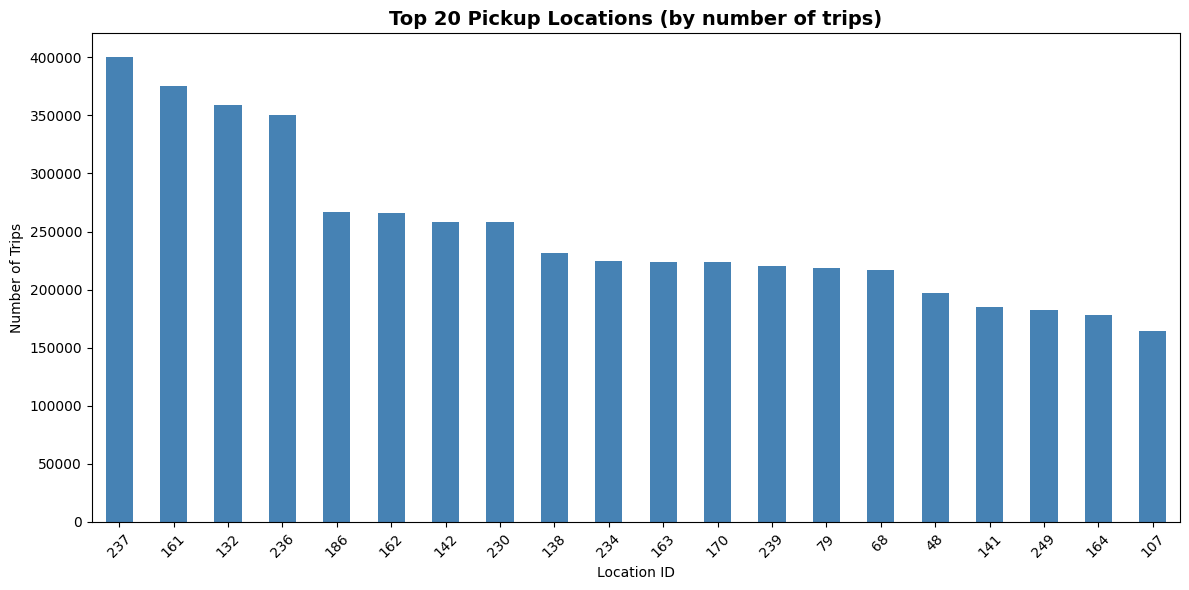


Most popular pickup location: Zone 237 with 400,535 trips


In [7]:
plt.figure(figsize=(12, 6))
top_locations = df['PULocationID'].value_counts().head(20)
top_locations.plot(kind='bar', color='steelblue')
plt.title('Top 20 Pickup Locations (by number of trips)', fontsize=14, fontweight='bold')
plt.xlabel('Location ID')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMost popular pickup location: Zone {top_locations.index[0]} with {top_locations.values[0]:,} trips")

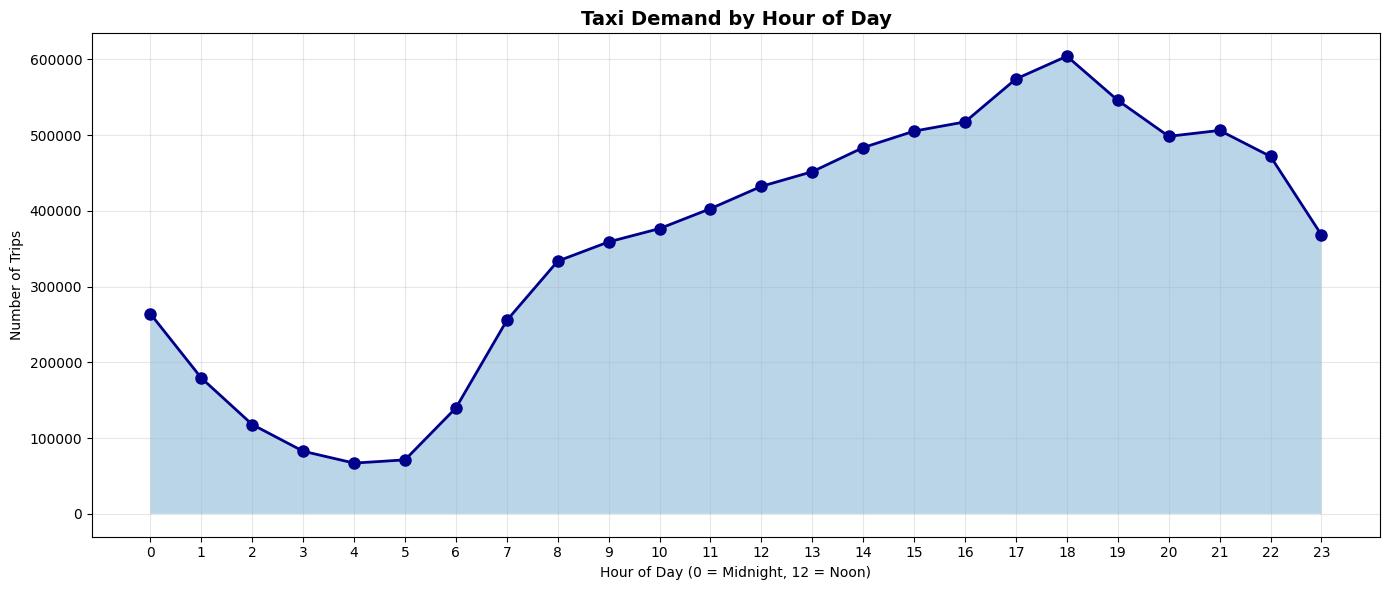

Peak hour: 18:00 with 604,250 trips
Lowest hour: 4:00 with 67,009 trips


In [8]:
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

# Plot demand by hour
plt.figure(figsize=(14, 6))
hourly_trips = df['pickup_hour'].value_counts().sort_index()
plt.plot(hourly_trips.index, hourly_trips.values, marker='o', linewidth=2, markersize=8, color='darkblue')
plt.fill_between(hourly_trips.index, hourly_trips.values, alpha=0.3)
plt.title('Taxi Demand by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Trips')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Peak hour: {hourly_trips.idxmax()}:00 with {hourly_trips.max():,} trips")
print(f"Lowest hour: {hourly_trips.idxmin()}:00 with {hourly_trips.min():,} trips")

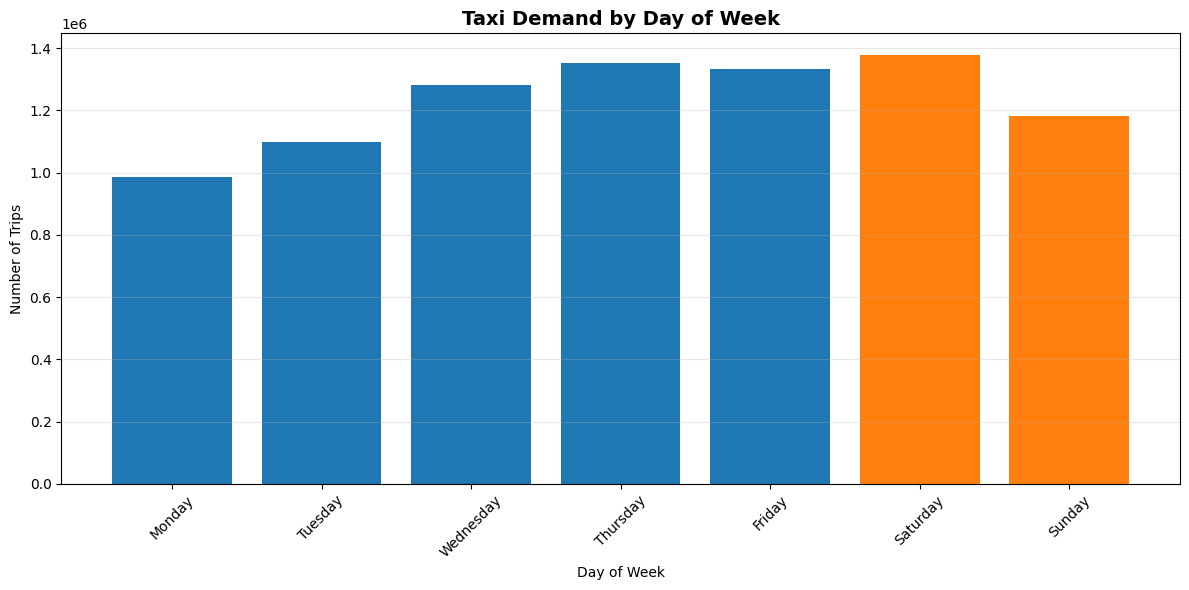

Busiest day: Saturday with 1,378,428 trips


In [9]:
df['day_of_week'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot
plt.figure(figsize=(12, 6))
daily_trips = df['day_of_week'].value_counts().sort_index()
plt.bar(range(7), daily_trips.values, color=['#1f77b4' if i < 5 else '#ff7f0e' for i in range(7)])
plt.title('Taxi Demand by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(range(7), day_names, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Busiest day: {day_names[daily_trips.idxmax()]} with {daily_trips.max():,} trips")